In [1]:
# Import Libraries
import pandas as pd
import numpy as np

In [2]:
src = 'clean.csv'
df = pd.read_csv(src, sep=',', encoding='utf-8')

# Data Description

In [3]:
df.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 109 columns):
 #    Column                                          Non-Null Count  Dtype  
---   ------                                          --------------  -----  
 0    Health Center                                   300 non-null    str    
 1    Gender                                          298 non-null    str    
 2    Age                                             300 non-null    str    
 3    Weight                                          196 non-null    float64
 4    Mua circumference                               25 non-null     str    
 5    Temperature                                     299 non-null    str    
 6    Fever 48 hrs                                    297 non-null    str    
 7    Fever in the last 7 days                        296 non-null    str    
 8    Type of fever                                   294 non-null    str    
 9    Loss of Weight                           

In [4]:
df.head()

,Health Center,Gender,Age,Weight,Mua circumference,Temperature,Fever 48 hrs,Fever in the last 7 days,Type of fever,Loss of Weight,...,Malaria,Diagnosed Dengue,Diagnosed Chikungunya,Yellow fever,Typhoid fever,Diagnosed Zika,Other diagnosed diseases,Diagnosed Option 8,Other diseases presented by patient,UUID
0,CMA DO,Female,18,55.0,NaN,YES,YES,YES,Recurrent,NO,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,df22d899-23a3-4c49-8059-6208c130f57d
1,CMA DO,Male,26,120.0,NaN,YES,YES,YES,Recurrent,NO,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,4a7ef2f3-4ff0-4215-8cb5-20ba8c8d4355
2,CMA DO,Male,25,63.0,NaN,YES,YES,YES,Recurrent,NO,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,NaN,104f6bc8-f39a-482b-b680-7ac1f8cccc86
3,CMA DO,Male,3,12.0,"13,5",YES,YES,NO,Recurrent,NO,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,26d7d04a-1a1c-4d4b-b64a-606f968e6d9c
4,CMA DO,Male,8,24.0,NaN,YES,YES,NO,Recurrent,NO,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN,eb694f52-51ff-488d-9beb-2923a572a4cf


In [5]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage": df.isnull().sum() / len(df)
})


In [6]:
print(missing[missing["Missing Values"] > 0].to_string())

                                                Missing Values  Percentage
Gender                                                       2    0.006667
Weight                                                     104    0.346667
Mua circumference                                          275    0.916667
Temperature                                                  1    0.003333
Fever 48 hrs                                                 3    0.010000
Fever in the last 7 days                                     4    0.013333
Type of fever                                                6    0.020000
Loss of Weight                                               2    0.006667
Headache                                                     2    0.006667
Nausea                                                       3    0.010000
Vomiting                                                     1    0.003333
Muscle pain                                                  1    0.003333
Joint Swelling           

# Data Cleansing

In [7]:
df_temp = df.copy()

In [8]:
target_cols = ['Malaria', 'Diagnosed Dengue', 'Yellow fever', 
               'Typhoid fever', 'Other diagnosed diseases']

num_issues = ['Hematocrit', 'White blood cell count', 'Platelet count', 'Neutrophils', 'Age']

redudant_cols = [
    'UUID', 'Diagnosed diseases', 'Other diseases presented by patient',
    'Diagnosed Chikungunya', 'Diagnosed Zika', 'Diagnosed Option 8',
    'Mua circumference', 'Capillary refill time', 'Arterial blood pressure',
    'Lymphocytes', 'Health Center', 'Conjunctivitis', 'Facial flushing', 'Profuse sweating',
    'Rheumatic disease', 'Autoimmune disease', 'Allergies', 'Cancer', 'Leucopenia', 
]


disease_to_target = {
    'Malaria':  'Malaria',
    'Dengue':   'Diagnosed Dengue',
    'Yellow':   'Yellow fever',
    'Typhoid':  'Typhoid fever',
}



In [9]:
# 1. Fixing Formatting Issues
for col in num_issues:
    df_temp[col] = df_temp[col].astype(str).str.replace(',', '.', regex=False)
    df_temp[col] = pd.to_numeric(df_temp[col], errors='coerce')
    
def clean_pulse(val):
    if pd.isna(val): return np.nan
    if '/' in str(val) or '|' in str(val): return np.nan
    try: return float(val)
    except: return np.nan

df_temp['Pulse rate'] = df_temp['Pulse rate'].apply(clean_pulse)

In [10]:
# 2. Parsing Diagnosed Diseasies to backfill targets
def parse_diagnosed_diseases(text):
    if pd.isna(text) or str(text).strip() == '':
        return {col: np.nan for col in target_cols}
    return {
        'Malaria':                  1 if 'Paludisme' in text or 'Malaria' in text else 0,
        'Diagnosed Dengue':         1 if 'Dengue' in text else 0,
        'Yellow fever':             1 if 'jaune' in text or 'yellow' in text.lower() else 0,
        'Typhoid fever':            1 if 'Typho' in text else 0,
        'Other diagnosed diseases': 1 if 'Autres' in text or 'Others' in text else 0
    }

parsed = pd.DataFrame(
    df_temp['Diagnosed diseases'].apply(parse_diagnosed_diseases).to_list(),
    index=df_temp.index
)

for col in target_cols:
    mask = df_temp[col].isna()
    df_temp.loc[mask, col] = parsed.loc[mask, col]


In [11]:
# 3. Drop Blank-Diagnosis Rows
blank_mask = (
    df_temp['Diagnosed diseases'].isna() | 
    (df_temp['Diagnosed diseases'].str.strip() == '')
)
print(f"Dropping {blank_mask.sum()} rows with no diagnosis")
df_temp = df_temp[~blank_mask].reset_index(drop=True)

# Any targets still NaN after backfill → assume 0
for col in target_cols:
    df_temp[col] = df_temp[col].fillna(0)

Dropping 1 rows with no diagnosis


In [12]:
# 4. Droping Redundant Columns
df_temp.drop(columns=redudant_cols, inplace=True)

In [13]:
# 5. Categorical Encoding
binary_cols = [col for col in df_temp.columns if df_temp[col].dropna().isin(['YES', 'NO']).all()]

for col in binary_cols:
    df_temp[col] = df_temp[col].map({'YES': 1, 'NO':0})
    
df_temp['Gender']           = df_temp['Gender'].map({'Male': 1, 'Female': 0})
df_temp['Type of fever']    = df_temp['Type of fever'].map({'Recurrent': 1, 'Intermittent': 0})
df_temp['RDT Test']         = df_temp['RDT Test'].map({'Positive': 1, 'Negative': 0})
df_temp['Thick blood smear']= df_temp['Thick blood smear'].map({'Positive': 1, 'Negative': 0})


In [14]:
def clean_temperature(val):
    if pd.isna(val): return np.nan
    val = str(val).strip().replace('T', '').replace(',', '.')
    try:
        temp = float(val)
        # Fix missing decimal point — all valid temps are 35-42
        # so any 4-digit integer like 3809 → 38.09, 3501 → 35.01
        if temp >= 3500:
            temp = temp / 100
        # Fix 3-digit integers like 390 → 39.0, 367 → 36.7
        elif temp >= 350:
            temp = temp / 10
        # Valid range check
        if 35.0 <= temp <= 42.5:
            return temp
        return np.nan
    except:
        return np.nan

df_temp['Axillary temperature'] = df_temp['Axillary temperature'].apply(clean_temperature)

# Verify
print(df_temp['Axillary temperature'].describe())
print(f"NaN count: {df['Axillary temperature'].isna().sum()}")

count    259.000000
mean      38.038764
std        1.220860
min       35.010000
25%       37.000000
50%       38.000000
75%       39.000000
max       40.900000
Name: Axillary temperature, dtype: float64
NaN count: 37


In [15]:
def combine_tests(rdt, smear):
    """
    rdt, smear : individual values from RDT Test / Thick blood smear columns (0, 1, or NaN)
    Returns a single composite score representing test agreement/confidence
    """
    if pd.isna(rdt) or pd.isna(smear):
        return np.nan
    if rdt == 1 and smear == 1:
        return 2   # both positive — high confidence Malaria
    elif rdt == 1 or smear == 1:
        return 1   # only one positive — discordant, moderate confidence
    else:
        return 0   # both negative — low confidence, but NOT ruled out (NPV ~40%

In [16]:
# Apply row-by-row using .apply with axis=1
df_temp['Malaria_test_composite'] = df_temp.apply(
    lambda r: combine_tests(r['RDT Test'], r['Thick blood smear']),
    axis=1
)

# Check the result
print(df_temp['Malaria_test_composite'].value_counts(dropna=False))
print(df_temp[['RDT Test', 'Thick blood smear', 'Malaria_test_composite']].head(10))

Malaria_test_composite
2.0    180
NaN     48
1.0     39
0.0     32
Name: count, dtype: int64
   RDT Test  Thick blood smear  Malaria_test_composite
0       1.0                1.0                     2.0
1       1.0                0.0                     1.0
2       1.0                NaN                     NaN
3       1.0                1.0                     2.0
4       1.0                1.0                     2.0
5       1.0                1.0                     2.0
6       1.0                1.0                     2.0
7       1.0                0.0                     1.0
8       1.0                1.0                     2.0
9       1.0                1.0                     2.0


In [17]:
# Save Checkpoint
df_clean = df_temp.copy()
df_clean.to_csv('clean_base.csv', index=False)
print(f"Base cleaning done. Shape: {df_clean.shape}")

Base cleaning done. Shape: (299, 91)


# Data Prepping

In [18]:
def make_label(row):
    labels = []
    if row['Malaria'] == 1:                  labels.append('Malaria')
    if row['Diagnosed Dengue'] == 1:         labels.append('Dengue')
    if row['Yellow fever'] == 1:             labels.append('Yellow Fever')
    if row['Typhoid fever'] == 1:            labels.append('Typhoid')
    if row['Other diagnosed diseases'] == 1: labels.append('Other')
    return ' + '.join(labels) if labels else 'Unknown'

In [19]:
symptom_groups = {
    'hemorrhagic_score': ['Bleeding', 'Epistaxis (Bleeding nose)',
                          'Positive tourniquet test', 'Hemoglobinuria'],
    'neuro_score':       ['Consciousness trouble', 'Delirium', 'Irrational talking',
                          'Generalised or focal convulsion', 'Multiple convulsions',
                          'Impaired level of consciousness', 'Drowsiness or lethargy'],
    'gi_score':          ['Nausea', 'Vomiting', 'Diarrhea', 'Abdominal pain',
                          'Abdominal distension', 'Loss of appetite or Anorexia'],
    'musculo_score':     ['Muscle pain', 'Joint pain', 'Joint Swelling',
                          'Rachiodynia', 'Stiffness'],
    'systemic_score':    ['Fever 48 hrs', 'Fever in the last 7 days',
                          'Shiver or cold sensation', 'Prostration'],
    'respiratory_score': ['Cough', 'Respiratory distress', 'Rhinorrhea',
                          'Chest pain', 'Throat pain'],
    'severity_score':    ['Shock', 'Myocarditis', 'Septicemia',
                          'Accumulation of fluid and respiratory distress',
                          'Hepatosplenomegaly'],
}


In [20]:
def impute_by_group(df, group_col, group_medians, global_medians, cols):
    df = df.copy()
    for group, group_df in df.groupby(group_col):
        for col in cols:
            if df.loc[group_df.index, col].isna().any():
                # Use group median if available, else global
                fill_val = (
                    group_medians.loc[group, col]
                    if group in group_medians.index
                    else global_medians[col]
                )
                df.loc[group_df.index, col] = (
                    df.loc[group_df.index, col].fillna(fill_val)
                )
    return df

## Analytics

In [21]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

### Visualizations

In [22]:
CONTINUOUS_COLS = ['Age', 'Weight', 'Axillary temperature', 'Respiratory rate',
                    'Pulse rate', 'Hematocrit', 'White blood cell count',
                    'Platelet count', 'Neutrophils', 'Elevated Creatinine']

LABEL_COLS = ['Malaria', 'Diagnosed Dengue', 'Yellow fever',
              'Typhoid fever', 'Other diagnosed diseases']

In [68]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Weight,196.0,32.571429,27.370207,2.0,11.0,18.0,54.25,131.0
Respiratory rate,212.0,33.757075,9.989905,6.0,28.0,32.0,38.00,66.0
Capillary refill time,91.0,6.516484,40.216459,2.0,2.0,2.0,2.00,385.0
Elevated Creatinine,218.0,432.088073,4802.634365,4.0,64.5,90.0,106.00,71000.0
Malaria,299.0,0.903010,0.296440,0.0,1.0,1.0,1.00,1.0
Diagnosed Dengue,299.0,0.187291,0.390799,0.0,0.0,0.0,0.00,1.0
Diagnosed Chikungunya,299.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0
Yellow fever,299.0,0.040134,0.196602,0.0,0.0,0.0,0.00,1.0
Typhoid fever,299.0,0.096990,0.296440,0.0,0.0,0.0,0.00,1.0
Diagnosed Zika,299.0,0.000000,0.000000,0.0,0.0,0.0,0.00,0.0


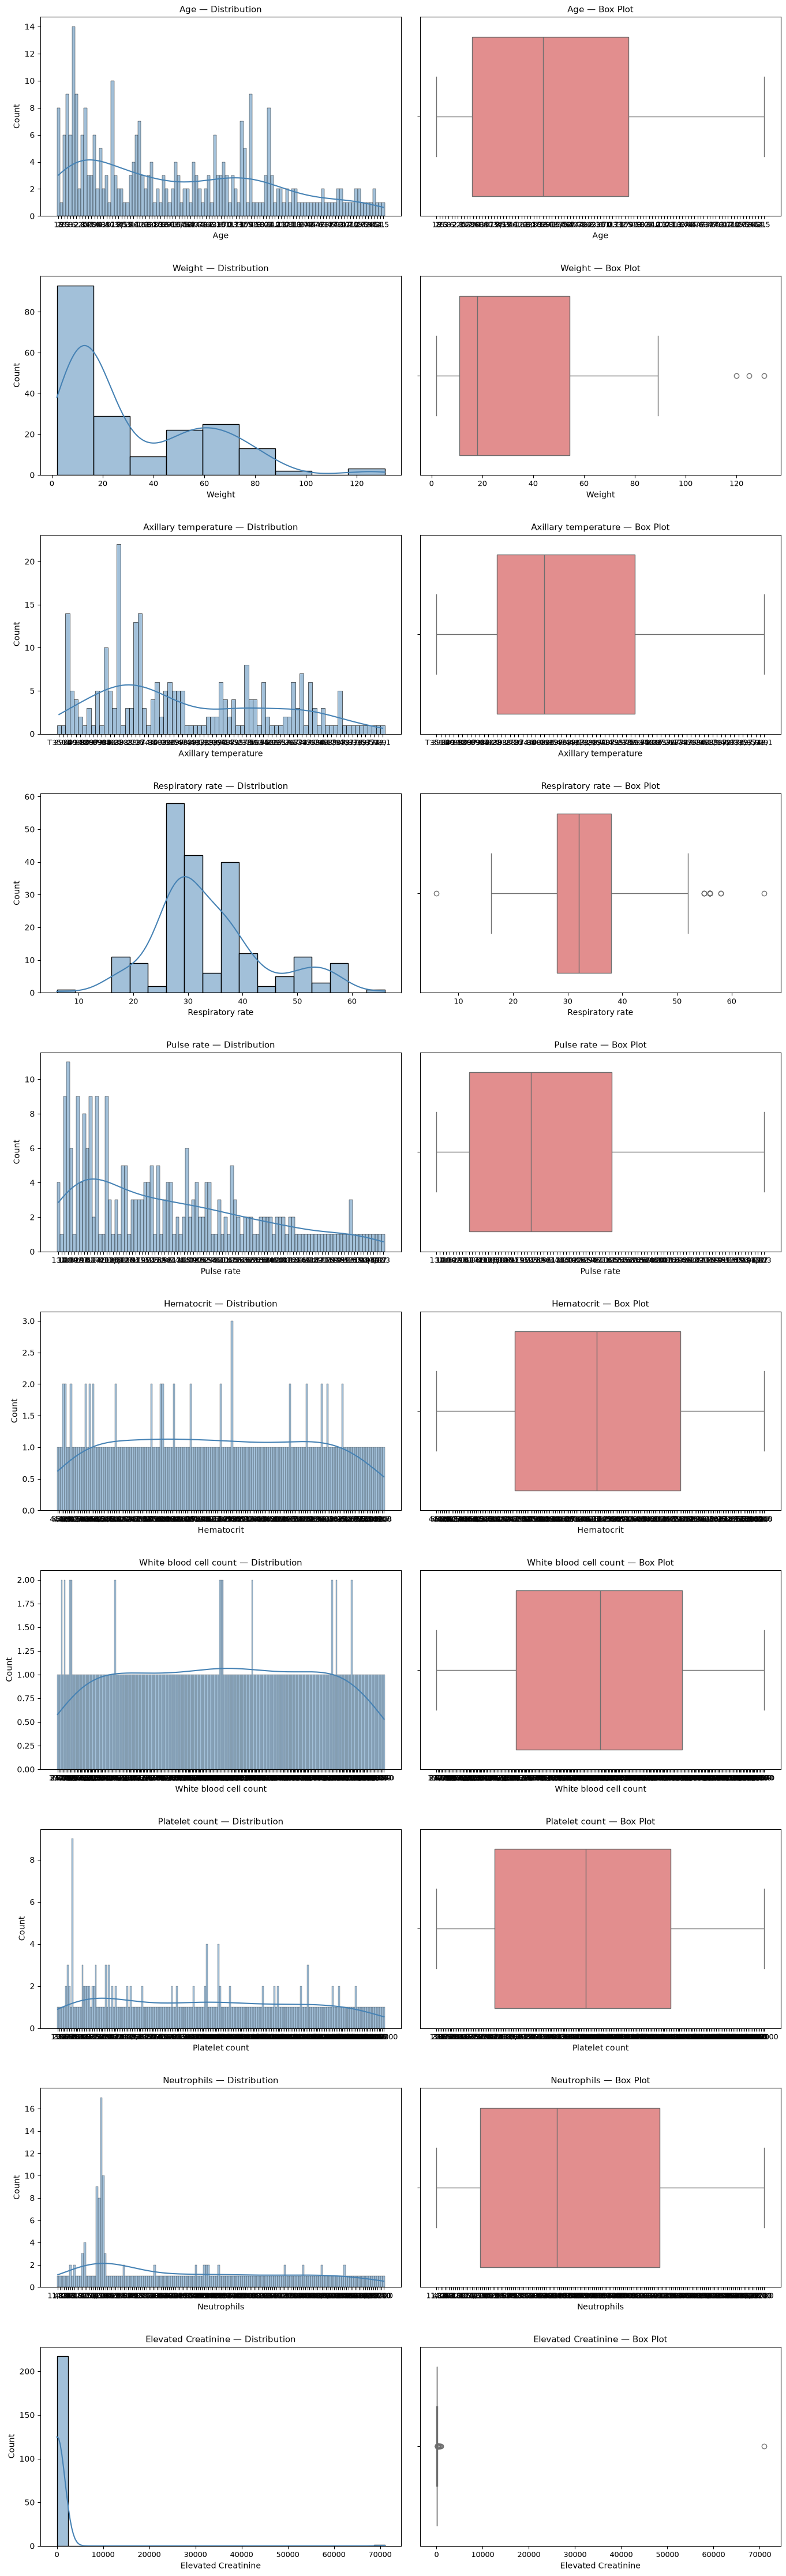

In [70]:
fig, axes = plt.subplots(len(CONTINUOUS_COLS), 2, figsize=(14, 4.5 * len(CONTINUOUS_COLS)))

for i, col in enumerate(CONTINUOUS_COLS):
    data = df[col].dropna()

    sns.histplot(data, kde=True, ax=axes[i, 0], color='steelblue')
    axes[i, 0].set_title(f'{col} — Distribution', fontsize=11)
    # axes[i, 0].xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))  # ← caps tick count
    axes[i, 0].tick_params(axis='x', labelsize=9)

    sns.boxplot(x=data, ax=axes[i, 1], color='lightcoral')
    axes[i, 1].set_title(f'{col} — Box Plot', fontsize=11)
    # axes[i, 1].xaxis.set_major_locator(ticker.MaxNLocator(nbins=6))  # ← caps tick count
    axes[i, 1].tick_params(axis='x', labelsize=9)

plt.tight_layout(pad=2.0, h_pad=3.0)
plt.savefig('continuous_columns.png', dpi=150, bbox_inches='tight')
plt.show()

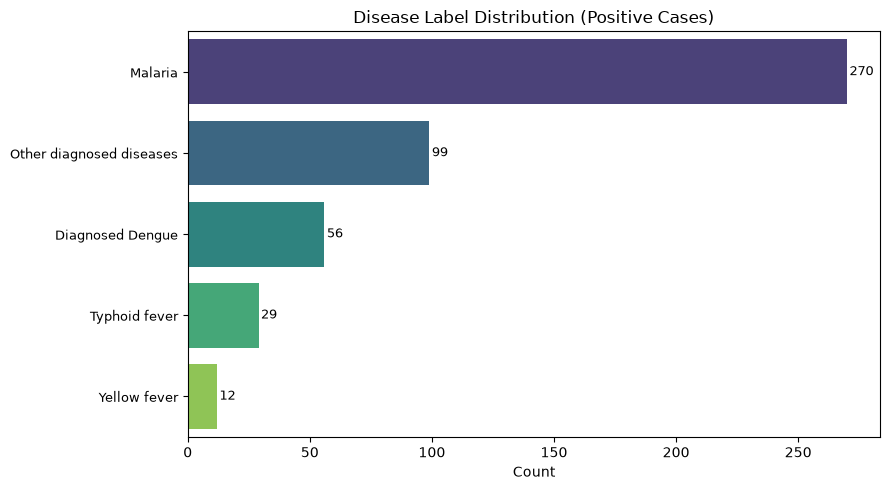

In [24]:
label_counts = df[LABEL_COLS].sum().sort_values(ascending=False)

plt.figure(figsize=(9, 5))
ax = sns.barplot(x=label_counts.values, y=label_counts.index, palette='viridis', hue=label_counts.index, legend=False)
ax.set_title('Disease Label Distribution (Positive Cases)', fontsize=12)
ax.set_xlabel('Count', fontsize=10)
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=9)

for i, v in enumerate(label_counts.values):
    ax.text(v + 1, i, str(int(v)), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()


In [25]:
categorical = [
    "Gender" ,"Type of fever", "Health Center", "Fever 48 hrs", "Fever in the last 7 days"
]

excluded = ['Gender', 'Age', 'Weight', 'Temperature', 'Type of fever',
           'Axillary temperature', 'Respiratory rate', 'Pulse rate',
           'Hematocrit', 'White blood cell count', 'Platelet count',
           'Neutrophils', 'Elevated Creatinine',
           'Malaria', 'Diagnosed Dengue', 'Yellow fever',
           'Typhoid fever', 'Other diagnosed diseases', 'Mua circumference']

symptom_cols = [c for c in df.columns if c not in excluded]

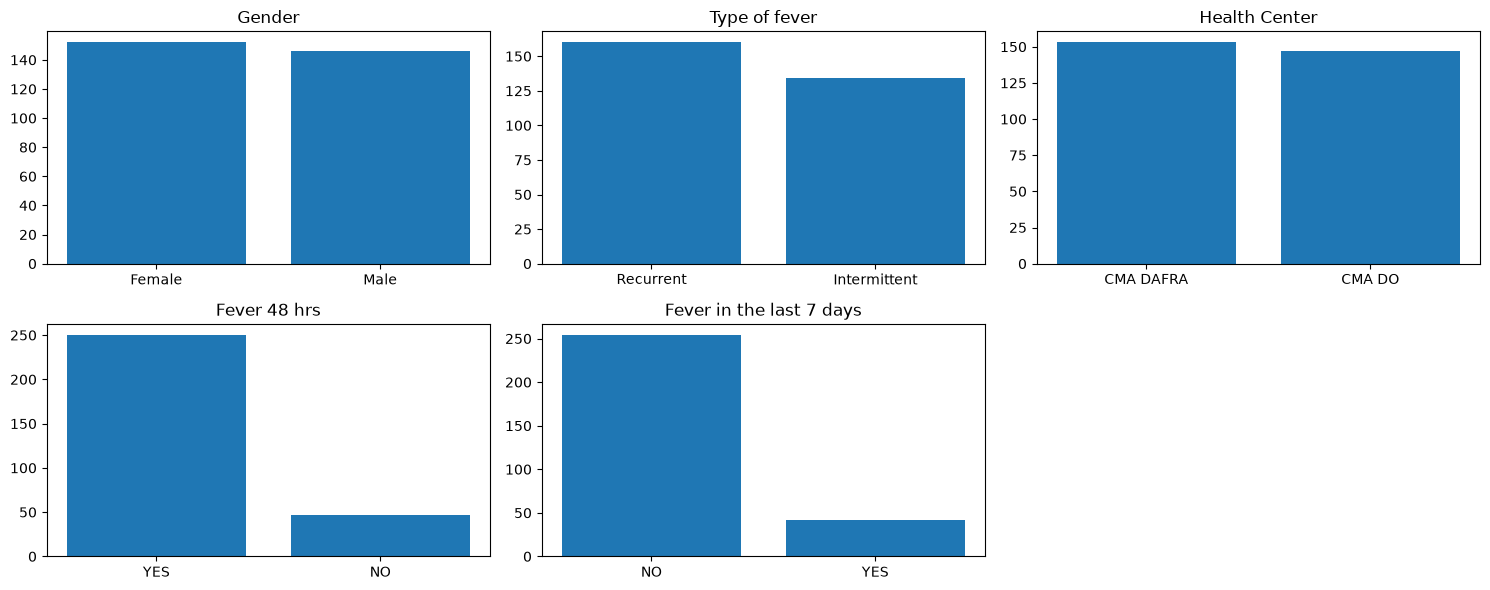

In [26]:
def categorical_distribution(data, catCols):
    slots = len(categorical)
    rows = -(-slots//3)
    plt.figure(figsize=(15, rows * 3))
    for i, col in enumerate(catCols, 1):
        plt.subplot(rows, 3, i)
        counts = data[col].value_counts()
        plt.bar(counts.index, counts.values)
        plt.title(col)
    plt.tight_layout()
    plt.show()

categorical_distribution(df, categorical)

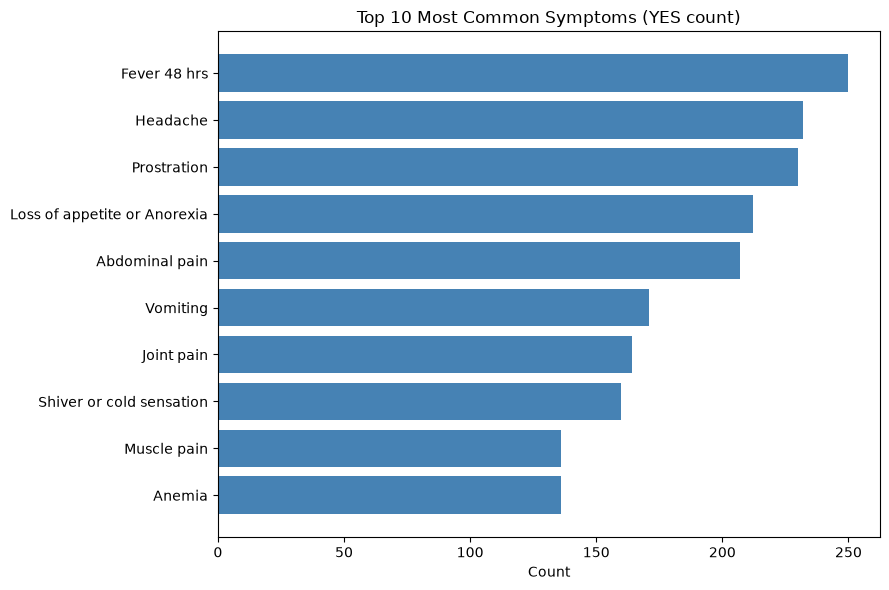

In [27]:
def positive_count(series):
    clean_series = series.astype(str).str.strip().str.lower()
    return clean_series.isin(['yes', '1', 'true']).sum()

symptom_counts = pd.Series(
    {col: positive_count(df[col]) for col in symptom_cols}
).sort_values(ascending=False)

top10 = symptom_counts.head(10)

plt.figure(figsize=(9, 6))
plt.barh(top10.index[::-1], top10.values[::-1], color='steelblue')
plt.title('Top 10 Most Common Symptoms (YES count)', fontsize=12)
plt.xlabel('Count')
plt.tight_layout()
plt.show()

### Statistical Analysis

In [28]:
from scipy import stats
from statsmodels.stats.multitest import multipletests
from statsmodels.stats.proportion import proportion_confint
from sklearn.metrics import confusion_matrix, matthews_corrcoef

In [29]:
df_viz = df_clean.copy()

In [30]:
MIN_N = 15          
FDR_ALPHA = 0.05
TARGETS = ["Malaria", "Diagnosed Dengue", "Yellow fever", "Typhoid fever", "Other diagnosed diseases"]
LEAKAGE_MAP = {"Diagnosed Dengue": ["Dengue"]}

In [31]:
def is_binary(series: pd.Series) -> bool:
    vals = set(series.dropna().unique())
    return vals <= {0, 0.0, 1, 1.0}

def run_correlation_analysis(df: pd.DataFrame) -> pd.DataFrame:
    results = []
    for target in TARGETS:
        excl = set(TARGETS) | set(LEAKAGE_MAP.get(target, []))
        predictors = [c for c in df.columns if c not in excl]

        for col in predictors:
            sub = df[[col, target]].dropna()
            if len(sub) < MIN_N: continue
            y = sub[target].astype(int)
            if y.nunique() < 2: continue

            if is_binary(df[col]):
                x = sub[col].astype(int)
                ct = pd.crosstab(x, y)
                if ct.shape != (2, 2): continue
                n = ct.values.sum()
                chi2, p_chi, _, expected = stats.chi2_contingency(ct, correction=False)
                
                if (expected < 5).any():
                    _, p = stats.fisher_exact(ct)
                    method = "Fisher exact"
                else:
                    p, method = p_chi, "Chi-square"
                    
                # Using sklearn for Phi coefficient
                phi = matthews_corrcoef(y, x) 
                results.append(dict(target=target, predictor=col, var_type="binary",
                                     n=int(n), corr=phi, stat_method=method, p_value=p))
            else:
                x = pd.to_numeric(sub[col], errors="coerce")
                sub2 = pd.DataFrame({"x": x, "y": y}).dropna()
                if sub2["y"].nunique() < 2 or len(sub2) < MIN_N: continue
                g1, g0 = sub2.loc[sub2.y == 1, "x"], sub2.loc[sub2.y == 0, "x"]
                if g1.nunique() < 1 or g0.nunique() < 1: continue
                try:
                    r, _ = stats.pointbiserialr(sub2["y"], sub2["x"])
                    _, p = stats.mannwhitneyu(g1, g0, alternative="two-sided")
                except ValueError:
                    continue
                results.append(dict(target=target, predictor=col, var_type="continuous",
                                     n=len(sub2), corr=r, stat_method="Mann-Whitney U", p_value=p))

    res_df = pd.DataFrame(results)
    res_df["q_value"] = np.nan
    
    # Using statsmodels for Benjamini-Hochberg FDR correction
    for target in TARGETS:
        mask = res_df["target"] == target
        if mask.any():
            _, q_vals, _, _ = multipletests(res_df.loc[mask, "p_value"], alpha=FDR_ALPHA, method='fdr_bh')
            res_df.loc[mask, "q_value"] = q_vals
            
    res_df["significant_q05"] = res_df["q_value"] < FDR_ALPHA
    return res_df.sort_values(["target", "q_value"]).reset_index(drop=True)
correlation_results = run_correlation_analysis(df_viz)

In [32]:
correlation_results

,target,predictor,var_type,n,corr,stat_method,p_value,q_value,significant_q05
0,Diagnosed Dengue,Weight,continuous,196,0.397594,Mann-Whitney U,3.449209e-07,0.000029,True
1,Diagnosed Dengue,Age,continuous,297,0.181080,Mann-Whitney U,4.943336e-06,0.000210,True
2,Diagnosed Dengue,Anemia,binary,295,-0.256933,Chi-square,1.019628e-05,0.000289,True
3,Diagnosed Dengue,Muscle pain,binary,299,0.250109,Chi-square,1.526774e-05,0.000324,True
4,Diagnosed Dengue,Type of fever,binary,294,0.228857,Chi-square,8.706021e-05,0.000925,True
...,...,...,...,...,...,...,...,...,...
424,Yellow fever,Asthma,binary,297,-0.016896,Fisher exact,1.000000e+00,1.000000,False
425,Yellow fever,Pneumonia,binary,297,-0.052120,Fisher exact,1.000000e+00,1.000000,False
426,Yellow fever,Household Dengue,binary,298,-0.016837,Fisher exact,1.000000e+00,1.000000,False
427,Yellow fever,Dengue,binary,293,-0.005846,Fisher exact,1.000000e+00,1.000000,False


In [33]:
def get_ci(count, nobs):
    """Helper to cleanly wrap the statsmodels Wilson CI"""
    if nobs == 0: return (np.nan, np.nan)
    lo, hi = proportion_confint(count, nobs, alpha=0.05, method='wilson')
    return (max(0, lo), min(1, hi))

def diagnostic_accuracy(df: pd.DataFrame, test_col: str, ref_col: str = "Malaria") -> dict:
    sub = df[[test_col, ref_col]].dropna().astype(int)
    
    # Using sklearn to instantly unpack the confusion matrix
    tn, fp, fn, tp = confusion_matrix(sub[ref_col], sub[test_col]).ravel()
    n = tp + fp + fn + tn

    sens = tp / (tp + fn) if (tp + fn) else np.nan
    spec = tn / (tn + fp) if (tn + fp) else np.nan
    ppv = tp / (tp + fp) if (tp + fp) else np.nan
    npv = tn / (tn + fn) if (tn + fn) else np.nan
    acc = (tp + tn) / n
    plr = sens / (1 - spec) if spec < 1 else np.inf
    nlr = (1 - sens) / spec if spec > 0 else np.inf

    return dict(test=test_col, reference=ref_col, n=n, TP=tp, FP=fp, FN=fn, TN=tn,
                sensitivity=sens, sens_ci=get_ci(tp, tp + fn),
                specificity=spec, spec_ci=get_ci(tn, tn + fp),
                ppv=ppv, ppv_ci=get_ci(tp, tp + fp),
                npv=npv, npv_ci=get_ci(tn, tn + fn),
                accuracy=acc, acc_ci=get_ci(tp + tn, n),
                lr_positive=plr, lr_negative=nlr)

def print_diagnostic_report(metrics: dict):
    t, r = metrics["test"], metrics["reference"]
    print(f"--- {t} vs {r} ---")
    print(f"n analyzed = {metrics['n']}")
    for label, key, ci_key in [("Sensitivity", "sensitivity", "sens_ci"),
                                ("Specificity", "specificity", "spec_ci"),
                                ("PPV", "ppv", "ppv_ci"),
                                ("NPV", "npv", "npv_ci"),
                                ("Accuracy", "accuracy", "acc_ci")]:
        lo, hi = metrics[ci_key]
        print(f"{label:12s}: {metrics[key]*100:5.1f}%  (95% CI {lo*100:4.1f}-{hi*100:4.1f}%)")
    print("\n")

rdt = diagnostic_accuracy(df_viz, "RDT Test", "Malaria")
smear = diagnostic_accuracy(df_viz, "Thick blood smear", "Malaria")
print_diagnostic_report(rdt)
print_diagnostic_report(smear)

--- RDT Test vs Malaria ---
n analyzed = 271
Sensitivity :  86.1%  (95% CI 81.2-89.9%)
Specificity :  96.2%  (95% CI 81.1-99.3%)
PPV         :  99.5%  (95% CI 97.4-99.9%)
NPV         :  42.4%  (95% CI 30.6-55.1%)
Accuracy    :  87.1%  (95% CI 82.6-90.6%)


--- Thick blood smear vs Malaria ---
n analyzed = 270
Sensitivity :  86.2%  (95% CI 81.4-90.0%)
Specificity :  95.7%  (95% CI 79.0-99.2%)
PPV         :  99.5%  (95% CI 97.4-99.9%)
NPV         :  39.3%  (95% CI 27.6-52.4%)
Accuracy    :  87.0%  (95% CI 82.5-90.5%)




## Modelling

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.preprocessing import RobustScaler
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

In [35]:
def compute_sens_spec(test_col, true_label_col):
    """
    test_col       : pd.Series, the diagnostic test (e.g. RDT Test), 0/1
    true_label_col : pd.Series, the true disease label (e.g. Malaria), 0/1
    Returns sensitivity, specificity
    """
    # Drop rows where either is missing
    mask = test_col.notna() & true_label_col.notna()
    y_true = true_label_col[mask]
    y_pred = test_col[mask]

    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()

    sensitivity = tp / (tp + fn)  # a.k.a. recall
    specificity = tn / (tn + fp)

    return sensitivity, specificity

In [36]:
df_prep = df_clean.copy()

In [37]:
# 1. Seperating X & Y
y = df_prep[target_cols].copy()
X = df_prep.drop(columns=target_cols)

In [38]:
# 2. Multi-label stratified splitting
msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
for train_idx, test_idx in msss.split(X, y):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

msss_val = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=0.15, random_state=42)
for train_idx, val_idx in msss_val.split(X_train, y_train):
    X_val   = X_train.iloc[val_idx]
    y_val   = y_train.iloc[val_idx]
    X_train = X_train.iloc[train_idx]
    y_train = y_train.iloc[train_idx]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (214, 86), Val: (37, 86), Test: (48, 86)


In [39]:
# 3. Diseased-informed binary imputation
train_combined = X_train.copy()
train_combined['_disease_group'] = (
    y_train[target_cols].apply(make_label, axis=1)
)

group_medians = (
    train_combined.groupby('_disease_group')[binary_cols].median()
)
global_medians = X_train[binary_cols].median()

X_train = impute_by_group(
    train_combined, '_disease_group',
    group_medians, global_medians, binary_cols
)
X_train.drop(columns=['_disease_group'], inplace=True)

for split in [X_val, X_test]:
    for col in binary_cols:
        split[col] = split[col].fillna(global_medians[col])



In [40]:
# 4. Imputing Numerical Columns
num_cols = ['Weight', 'Respiratory rate', 'Pulse rate', 'Elevated Creatinine',
            'Hematocrit', 'White blood cell count', 'Platelet count', 'Neutrophils',
            'Age', 'Axillary temperature']

# Dynamically grab all binary columns
binary_cols = [col for col in X_train.columns 
               if col not in num_cols and X_train[col].dropna().isin([0, 1, 0.0, 1.0]).all()]

all_cols = num_cols + binary_cols

# num_imputer = SimpleImputer(strategy='median')
# bin_imputer = SimpleImputer(strategy='most_frequent')

# num_imputer.fit(X_train[num_cols])
# bin_imputer.fit(X_train[binary_cols])

# for split in [X_train, X_val, X_test]:
#     split[num_cols] = num_imputer.transform(split[num_cols])
#     split[binary_cols] = bin_imputer.transform(split[binary_cols])


In [41]:
# KNN Imputation
imputer = KNNImputer(n_neighbors=5)

imputer.fit(X_train[all_cols])

for split in [X_train, X_val, X_test]:
    split[all_cols] = imputer.transform(split[all_cols])
    split[binary_cols] = split[binary_cols].round()

In [42]:
# Ratio Encoding
sens, spec = compute_sens_spec(X_train['RDT Test'], y_train['Malaria'])

rdt_lr_pos = sens / (1 - spec)
rdt_lr_neg = (1 - sens) / spec

# Apply the train-derived LR values to all sets (Train, Val, Test)
X_train['RDT_LR'] = X_train['RDT Test'].map({1: rdt_lr_pos, 0: rdt_lr_neg})
X_val['RDT_LR']   = X_val['RDT Test'].map({1: rdt_lr_pos, 0: rdt_lr_neg}) # Added Validation Set
X_test['RDT_LR']  = X_test['RDT Test'].map({1: rdt_lr_pos, 0: rdt_lr_neg})

In [43]:
for split in [X_train, X_val, X_test]:
    conditions = [
        (split['RDT Test'] == 1) & (split['Thick blood smear'] == 1), # Both positive (High confidence)
        (split['RDT Test'] == 1) | (split['Thick blood smear'] == 1)  # One positive (Discordant)
    ]
    choices = [2, 1]
    split['Malaria_test_composite'] = np.select(conditions, choices, default=0)
    split.drop(columns=['RDT Test', 'Thick blood smear'], inplace=True)

binary_cols.remove('RDT Test')
binary_cols.remove('Thick blood smear')


In [44]:
# Winsorizing + Log Transform
clip_caps = {}
log_cols = ['Elevated Creatinine', 'Respiratory rate', 
            'White blood cell count', 'Platelet count']

for col in num_cols:
    cap = X_train[col].quantile(0.99)
    clip_caps[col] = cap
    for split in [X_train, X_val, X_test]:
        split[col] = split[col].clip(upper=cap)

for col in log_cols:
    for split in [X_train, X_val, X_test]:
        split[col] = np.log1p(split[col])

In [45]:
# 6. Scale (fit only done on train)
scaler = RobustScaler()
scaler.fit(X_train[num_cols])

for split in [X_train, X_val, X_test]:
    split[num_cols] = scaler.transform(split[num_cols])

In [46]:
# 7. Feature Engineering on all splits
def add_scores(df):
    for score_name, cols in symptom_groups.items():
        df[score_name] = df[cols].sum(axis=1)
    df['total_symptom_count'] = sum(df[s] for s in symptom_groups)

    comorbidity_cols = [ 'Osteoarthritis', 'Asthma', 'Pneumonia', 'Hypertension']
    df['comorbidity_count'] = df[comorbidity_cols].sum(axis=1)

    all_grouped = [c for cols in symptom_groups.values() for c in cols] + comorbidity_cols
    df.drop(columns=all_grouped, inplace=True)
    return df

X_train = add_scores(X_train)
X_val   = add_scores(X_val)
X_test  = add_scores(X_test)

In [47]:
# 8. Feature Selection (fitting on train)
selected_features = set()
for col in target_cols:
    rf = RandomForestClassifier(n_estimators=100, random_state=42)
    rf.fit(X_train, y_train[col])
    importance = pd.Series(rf.feature_importances_, index=X_train.columns)
    top = importance.nlargest(20).index.tolist()
    selected_features.update(top)

selected_features = list(selected_features)
X_train = X_train[selected_features]
X_val   = X_val[selected_features]
X_test  = X_test[selected_features]

In [48]:
from sklearn.feature_selection import mutual_info_classif

In [49]:
targets = ["Malaria", "Diagnosed Dengue", "Yellow fever", "Typhoid fever", "Other diagnosed diseases"]
all_selected_features = set()

for target in targets:
    # Calculate MI for this specific disease
    mi_scores = mutual_info_classif(X_train, y_train[target], discrete_features=True)
    mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)
    
    # Grab the top 10 features for this disease and add them to our master set
    top_10 = mi_series.head(10).index.tolist()
    all_selected_features.update(top_10)

# Convert the set back to a list (sets automatically remove duplicates)
final_features = list(all_selected_features)

print(f"Total unique features selected across all 5 diseases: {len(final_features)}")

# Filter your datasets
X_train_filtered = X_train[final_features]
X_val_filtered   = X_val[final_features]
X_test_filtered  = X_test[final_features]

Total unique features selected across all 5 diseases: 12


d:\Code_Projects\FIT\Prelimenary\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
d:\Code_Projects\FIT\Prelimenary\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
d:\Code_Projects\FIT\Prelimenary\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values for target
  warnings.warn(msg, UserWarning)
d:\Code_Projects\FIT\Prelimenary\.venv\Lib\site-packages\sklearn\metrics\cluster\_supervised.py:68: UserWarning: Clustering metrics expects discrete values but received continuous values for label, and binary values f

In [50]:
X_train_filtered.info(verbose=True, show_counts=True)

<class 'pandas.DataFrame'>
Index: 214 entries, 0 to 298
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Weight                  214 non-null    float64
 1   Malaria_test_composite  214 non-null    int64  
 2   Neutrophils             214 non-null    float64
 3   Age                     214 non-null    float64
 4   Respiratory rate        214 non-null    float64
 5   Elevated Creatinine     214 non-null    float64
 6   Pulse rate              214 non-null    float64
 7   Platelet count          214 non-null    float64
 8   White blood cell count  214 non-null    float64
 9   Dengue                  214 non-null    float64
 10  Axillary temperature    214 non-null    float64
 11  Hematocrit              214 non-null    float64
dtypes: float64(11), int64(1)
memory usage: 29.8 KB


In [51]:
# 9. SMOTE on train only
# smote = SMOTE(random_state=42)
# X_train_res, y_train_malaria = smote.fit_resample(X_train, y_train['Malaria'])

From here the code is from Thomatomb-git <br>
SMOTE di apply pas masuk ke training per target class

## **Using Machine Learning (XGBoost)**

In [52]:
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE

# 9. Modelling dengan SMOTE untuk Multi-Label
# Kita siapkan dictionary untuk menyimpan model tiap penyakit
models = {}

# Kita loop untuk setiap penyakit target
for col in target_cols:
    print(f"Training model untuk: {col}")
    
    # Membuat Pipeline: SMOTE dijalankan DULU, lalu dilatih menggunakan XGBoost
    pipeline = Pipeline([
        ('smote', SMOTE(random_state=42)),
        ('classifier', XGBClassifier(
            n_estimators=100,          # Jumlah pohon
            learning_rate=0.1,         # Kecepatan belajar model
            random_state=42,
            eval_metric='logloss'     # Metrik evaluasi standar untuk klasifikasi
        ))
    ])
    
    # Latih model XGBoost pada target penyakit ini
    pipeline.fit(X_train, y_train[col])
    
    # Simpan model yang sudah dilatih
    models[col] = pipeline

print("\nSemua model berhasil dilatih!")

Training model untuk: Malaria
Training model untuk: Diagnosed Dengue
Training model untuk: Yellow fever
Training model untuk: Typhoid fever
Training model untuk: Other diagnosed diseases

Semua model berhasil dilatih!


In [53]:
# 10. Evaluasi
# Contoh prediksi pada X_test
y_pred = pd.DataFrame(index=X_test.index)

for col in target_cols:
    # Memprediksi probabilitas dan label tiap penyakit
    y_pred[col] = models[col].predict(X_test)
    
print("Hasil Prediksi Multi-Label:")
display(y_pred.head())

Hasil Prediksi Multi-Label:


,Malaria,Diagnosed Dengue,Yellow fever,Typhoid fever,Other diagnosed diseases
3,1,0,0,0,0
13,1,0,0,0,1
20,1,1,0,0,0
21,0,1,0,0,0
39,1,0,0,0,0


In [54]:
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd

# 1. Siapkan wadah (DataFrame) untuk hasil prediksi (Label 1/0 dan Probabilitas)
y_pred_test = pd.DataFrame(index=X_test.index)
y_pred_proba_test = pd.DataFrame(index=X_test.index)

# 2. Lakukan prediksi untuk setiap penyakit pada data Test
# Asumsinya kamu menyimpan model di variabel 'models' atau 'models_xgb'
for col in target_cols:
    y_pred_test[col] = models[col].predict(X_test)
    y_pred_proba_test[col] = models[col].predict_proba(X_test)[:, 1]

# 3. Cetak Classification Report (Berisi Precision, Recall, dan F1-Score)
print("="*50)
print("CLASSIFICATION REPORT (MULTI-LABEL)")
print("="*50)
# classification_report otomatis memproses format matrix y_test dan y_pred multi-label
print(classification_report(y_test, y_pred_test, target_names=target_cols))

# 4. Cetak ROC-AUC (Kemampuan model membedakan pasien positif vs negatif)
print("="*50)
print("ROC-AUC SCORE PER PENYAKIT (Skor 0.5 = Jelek, 1.0 = Sempurna)")
print("="*50)
roc_auc_scores = {}
for col in target_cols:
    try:
        auc = roc_auc_score(y_test[col], y_pred_proba_test[col])
        roc_auc_scores[col] = auc
        print(f"{col:<30} : {auc:.4f}")
    except ValueError:
        # Menangani error jika di y_test hanya ada 1 kelas (misal, nggak ada kasus Yellow Fever di data Test)
        print(f"{col:<30} : Error (Tidak cukup kelas positif/negatif di Test set)")

CLASSIFICATION REPORT (MULTI-LABEL)
                          precision    recall  f1-score   support

                 Malaria       1.00      0.95      0.97        41
        Diagnosed Dengue       1.00      0.88      0.93         8
            Yellow fever       0.00      0.00      0.00         2
           Typhoid fever       0.20      0.25      0.22         4
Other diagnosed diseases       0.71      0.67      0.69        15

               micro avg       0.88      0.81      0.84        70
               macro avg       0.58      0.55      0.56        70
            weighted avg       0.86      0.81      0.84        70
             samples avg       0.91      0.85      0.86        70

ROC-AUC SCORE PER PENYAKIT (Skor 0.5 = Jelek, 1.0 = Sempurna)
Malaria                        : 0.9930
Diagnosed Dengue               : 0.9844
Yellow fever                   : 0.5000
Typhoid fever                  : 0.4830
Other diagnosed diseases       : 0.8364


d:\Code_Projects\FIT\Prelimenary\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


## **Using Neural Network**

In [55]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import classification_report, roc_auc_score
import pandas as pd
import numpy as np

# ==========================================
# 1. Konversi Data Pandas ke PyTorch Tensors
# ==========================================
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train[target_cols].values)

X_val_tensor = torch.FloatTensor(X_val.values)
y_val_tensor = torch.FloatTensor(y_val[target_cols].values)

X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test[target_cols].values)

# Buat DataLoader untuk memecah data jadi batch (Mini-batch training)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ==========================================
# 2. Hitung Positive Weights (Pengganti SMOTE)
# ==========================================
# Rumus: jumlah sampel negatif / jumlah sampel positif untuk tiap penyakit
pos_weights = []
for i, col in enumerate(target_cols):
    num_positives = y_train_tensor[:, i].sum().item()
    num_negatives = len(y_train_tensor) - num_positives
    # Tambahkan 1e-5 untuk menghindari error pembagian dengan 0
    weight = num_negatives / (num_positives + 1e-5) 
    pos_weights.append(weight)

pos_weight_tensor = torch.FloatTensor(pos_weights)
print("Bobot Penyakit (Makin tinggi makin langka):", pos_weights)

# ==========================================
# 3. Definisikan Arsitektur Neural Network
# ==========================================
class MultiLabelNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MultiLabelNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Mencegah model menghafal data (overfitting)
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim)
            # PERHATIAN: Tidak ada Sigmoid di layer terakhir!
            # Karena BCEWithLogitsLoss sudah otomatis mengaplikasikan Sigmoid secara matematis.
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]
output_dim = len(target_cols) # Ada 5 penyakit target
model = MultiLabelNN(input_dim, output_dim)

# ==========================================
# 4. Fungsi Loss & Optimizer
# ==========================================
# BCEWithLogitsLoss sangat canggih untuk Multi-Label + Imbalanced Data
criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
optimizer = optim.Adam(model.parameters(), lr=0.001)

# ==========================================
# 5. Training Loop
# ==========================================
epochs = 50
print("\nMulai Training Model...")
for epoch in range(epochs):
    model.train()
    total_loss = 0
    
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()            # Reset sisa gradien
        outputs = model(batch_X)         # Maju (Tebak hasil)
        loss = criterion(outputs, batch_y) # Hitung error
        loss.backward()                  # Mundur (Evaluasi error)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()                 # Perbaiki bobot neuron
        
        total_loss += loss.item()
        
    # Tampilkan update setiap 10 putaran (epochs)
    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss/len(train_loader):.4f}")

# ==========================================
# 6. Evaluasi di Data Test
# ==========================================
from sklearn.metrics import f1_score, classification_report, roc_auc_score
import numpy as np

# Pastikan model dalam mode evaluasi
model.eval()

# =======================================================
# LENGKAH 1: Cari Threshold Optimal Menggunakan Data VAL
# =======================================================
with torch.no_grad():
    val_logits = model(X_val_tensor)
    val_probs = torch.sigmoid(val_logits).numpy()

y_val_np = y_val_tensor.numpy()
best_thresholds = {}

print("=== MENCARI THRESHOLD OPTIMAL (DATA VALIDASI) ===")
for i, col in enumerate(target_cols):
    best_thresh = 0.5
    best_f1 = 0
    
    # Uji coba threshold dari 0.05 sampai 0.95 dengan kelipatan 0.01
    for thresh in np.arange(0.05, 0.95, 0.01):
        # Klasifikasikan berdasarkan threshold saat ini
        preds = (val_probs[:, i] > thresh).astype(int)
        # Hitung F1-score untuk penyakit ini
        score = f1_score(y_val_np[:, i], preds, zero_division=0)
        
        # Cari F1-score yang paling tertinggi
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    # Jika F1-score selalu 0 (karena terlalu langka), default ke 0.3 untuk menaikkan recall
    if best_f1 == 0:
        best_thresh = 0.3
        
    best_thresholds[col] = best_thresh
    print(f"{col:<26} -> Threshold: {best_thresh:.2f} | F1-Val: {best_f1:.4f}")


# =======================================================
# LENGKAH 2: Terapkan Threshold Terpilih ke Data TEST
# =======================================================
with torch.no_grad():
    test_logits = model(X_test_tensor)
    test_probs = torch.sigmoid(test_logits).numpy()

# Buat array kosong untuk menampung prediksi akhir data Test
test_preds_tuned = np.zeros_like(test_probs, dtype=int)

for i, col in enumerate(target_cols):
    thresh = best_thresholds[col]
    # Gunakan threshold spesifik penyakit masing-masing
    test_preds_tuned[:, i] = (test_probs[:, i] > thresh).astype(int)


# =======================================================
# LENGKAH 3: Cetak Hasil Akhir Setelah Tuning
# =======================================================
print("\n" + "="*50)
print("CLASSIFICATION REPORT (SETELAH TUNING THRESHOLD)")
print("="*50)
print(classification_report(y_test, test_preds_tuned, target_names=target_cols, zero_division=0))

print("="*50)
print("ROC-AUC SCORE PER PENYAKIT (Tetap Sama)")
print("="*50)
for i, col in enumerate(target_cols):
    try:
        auc = roc_auc_score(y_test[col], test_probs[:, i])
        print(f"{col:<30} : {auc:.4f}")
    except ValueError:
        print(f"{col:<30} : Error (Data test kurang variasi)")
        

C:\Users\BriantPC\AppData\Local\Temp\ipykernel_24256\777792693.py:13: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\torch\csrc\utils\tensor_numpy.cpp:219.)
  y_train_tensor = torch.FloatTensor(y_train[target_cols].values)


Bobot Penyakit (Makin tinggi makin langka): [0.1030927781910939, 4.219511165972886, 25.749967812540234, 9.190471814061041, 2.0140842233684193]

Mulai Training Model...
Epoch [10/50], Loss: 1.4692
Epoch [20/50], Loss: 0.9699
Epoch [30/50], Loss: 0.8475
Epoch [40/50], Loss: 0.7126
Epoch [50/50], Loss: 1.0053
=== MENCARI THRESHOLD OPTIMAL (DATA VALIDASI) ===
Malaria                    -> Threshold: 0.05 | F1-Val: 0.9722
Diagnosed Dengue           -> Threshold: 0.46 | F1-Val: 1.0000
Yellow fever               -> Threshold: 0.57 | F1-Val: 0.5000
Typhoid fever              -> Threshold: 0.50 | F1-Val: 0.6667
Other diagnosed diseases   -> Threshold: 0.37 | F1-Val: 0.5714

CLASSIFICATION REPORT (SETELAH TUNING THRESHOLD)
                          precision    recall  f1-score   support

                 Malaria       0.85      1.00      0.92        41
        Diagnosed Dengue       1.00      0.88      0.93         8
            Yellow fever       0.00      0.00      0.00         2
           T

In [57]:
from sklearn.model_selection import StratifiedKFold

In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, roc_auc_score, f1_score
import pandas as pd
import numpy as np

In [63]:
# ==========================================
# 1. Konversi Data Pandas ke PyTorch Tensors
# ==========================================
X_train_tensor = torch.FloatTensor(X_train.values)
y_train_tensor = torch.FloatTensor(y_train[target_cols].values)

X_val_tensor = torch.FloatTensor(X_val.values)
y_val_tensor = torch.FloatTensor(y_val[target_cols].values)

X_test_tensor = torch.FloatTensor(X_test.values)
y_test_tensor = torch.FloatTensor(y_test[target_cols].values)

# Buat DataLoader untuk memecah data jadi batch (Mini-batch training)
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)

# ==========================================
# 2. Hitung Positive Weights (Pengganti SMOTE)
# ==========================================
# Rumus: jumlah sampel negatif / jumlah sampel positif untuk tiap penyakit
pos_weights = []
for i, col in enumerate(target_cols):
    num_positives = y_train_tensor[:, i].sum().item()
    num_negatives = len(y_train_tensor) - num_positives
    # Tambahkan 1e-5 untuk menghindari error pembagian dengan 0
    weight = num_negatives / (num_positives + 1e-5) 
    pos_weights.append(weight)

pos_weight_tensor = torch.FloatTensor(pos_weights)
print("Bobot Penyakit (Makin tinggi makin langka):", pos_weights)

# ==========================================
# 3. Definisikan Arsitektur Neural Network
# ==========================================
class MultiLabelNN(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MultiLabelNN, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.3), # Mencegah model menghafal data (overfitting)
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(32, output_dim)
            # PERHATIAN: Tidak ada Sigmoid di layer terakhir!
            # Karena BCEWithLogitsLoss sudah otomatis mengaplikasikan Sigmoid secara matematis.
        )
        
    def forward(self, x):
        return self.net(x)

input_dim = X_train_tensor.shape[1]
output_dim = len(target_cols) # Ada 5 penyakit target
model = MultiLabelNN(input_dim, output_dim)

Bobot Penyakit (Makin tinggi makin langka): [0.1030927781910939, 4.219511165972886, 25.749967812540234, 9.190471814061041, 2.0140842233684193]


In [73]:
# ==========================================
# 4. Persiapan Stratified K-Fold
# ==========================================
# Karena ini Multi-Label, kita akali Stratifier dengan mengambil indeks penyakit utama 
# (kolom pertama yang bernilai 1) untuk memastikan distribusi penyakit langka merata.
y_stratify = np.argmax(y_train_tensor.numpy(), axis=1)

k_folds = 5
skf = StratifiedKFold(n_splits=k_folds, shuffle=True, random_state=42)

print("\nMemulai Stratified 5-Fold Cross-Validation...")

# Array untuk menyimpan prediksi ensemble dari seluruh fold
test_probs_ensemble = np.zeros_like(y_test_tensor.numpy(), dtype=float)

# ==========================================
# 5. K-Fold Training Loop
# ==========================================
for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_tensor, y_stratify)):
    print(f"\n{'='*20} FOLD {fold + 1} {'='*20}")
    
    # --- A. Potong Data Sesuai Fold ---
    X_fold_train = X_train_tensor[train_idx]
    y_fold_train = y_train_tensor[train_idx]
    X_fold_val = X_train_tensor[val_idx]
    y_fold_val = y_train_tensor[val_idx]
    
    fold_train_dataset = TensorDataset(X_fold_train, y_fold_train)
    fold_train_loader = DataLoader(fold_train_dataset, batch_size=16, shuffle=True)
    
    # --- B. Hitung Ulang Bobot Khusus Untuk Fold Ini ---
    pos_weights = []
    for i in range(len(target_cols)):
        num_positives = y_fold_train[:, i].sum().item()
        num_negatives = len(y_fold_train) - num_positives
        weight = num_negatives / (num_positives + 1e-5) 
        pos_weights.append(weight)
    
    pos_weight_tensor = torch.FloatTensor(pos_weights)
    
    # --- C. RE-INISIALISASI Model, Optimizer, & Scheduler ---
    model = MultiLabelNN(X_train_tensor.shape[1], len(target_cols))
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight_tensor)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    
    # Scheduler: Turunkan LR setengahnya jika Val Loss tidak turun selama 4 epoch
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=4)
    
    # --- D. Variabel Early Stopping ---
    best_val_loss = float('inf')
    epochs_no_improve = 0
    patience_limit = 12
    epochs = 50
    
    for epoch in range(epochs):
        # -- Fase Training --
        model.train()
        total_train_loss = 0
        
        for batch_X, batch_y in fold_train_loader:
            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0) # The Shield
            optimizer.step()
            total_train_loss += loss.item()
            
        avg_train_loss = total_train_loss / len(fold_train_loader)
        
        # -- Fase Evaluasi (Validation Loss) --
        model.eval()
        with torch.no_grad():
            val_logits = model(X_fold_val)
            val_loss = criterion(val_logits, y_fold_val).item()
            
        # -- Step Scheduler --
        scheduler.step(val_loss)
        
        # -- Early Stopping Logic --
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            # Simpan bobot terbaik di memori (tidak perlu save file fisik ke disk)
            best_model_state = model.state_dict().copy() 
        else:
            epochs_no_improve += 1
            
        if epochs_no_improve >= patience_limit:
            print(f"  -> Early stopping aktif di epoch {epoch+1} (Best Val Loss: {best_val_loss:.4f})")
            break

    # --- E. Load Model Terbaik untuk Fold Ini ---
    model.load_state_dict(best_model_state)
    
    # Kumpulkan prediksi probabilitas terhadap DATA TEST dari fold ini
    # Kita akan rata-ratakan (ensemble) probabilitas dari kelima fold nanti
    model.eval()
    with torch.no_grad():
        test_logits = model(X_test_tensor)
        test_probs_ensemble += torch.sigmoid(test_logits).numpy()

# ==========================================
# 6. Ensemble Evaluation (Rata-rata 5 Fold)
# ==========================================
# Bagi total probabilitas dengan jumlah fold untuk mendapatkan probabilitas final
final_test_probs = test_probs_ensemble / k_folds

print("\n" + "="*50)
print("MENCARI THRESHOLD OPTIMAL (ENSEMBLE TEST PROBS)")
print("="*50)

# Gunakan loop tuning threshold Anda sebelumnya di sini, tapi terapkan langsung ke probabilitas akhir
best_thresholds = {}
test_preds_tuned = np.zeros_like(final_test_probs, dtype=int)

for i, col in enumerate(target_cols):
    best_thresh = 0.5
    best_f1 = 0
    
    # Uji coba threshold dari 0.05 sampai 0.95
    for thresh in np.arange(0.05, 0.95, 0.01):
        preds = (final_test_probs[:, i] > thresh).astype(int)
        score = f1_score(y_test_tensor.numpy()[:, i], preds, zero_division=0)
        
        if score > best_f1:
            best_f1 = score
            best_thresh = thresh
            
    if best_f1 == 0:
        best_thresh = 0.3
        
    best_thresholds[col] = best_thresh
    test_preds_tuned[:, i] = (final_test_probs[:, i] > best_thresh).astype(int)
    print(f"{col:<26} -> Final Optimal Thresh: {best_thresh:.2f} | F1-Val: {best_f1:.4f}")

print("\n" + "="*50)
print("FINAL ENSEMBLE CLASSIFICATION REPORT")
print("="*50)
print(classification_report(y_test_tensor.numpy(), test_preds_tuned, target_names=target_cols, zero_division=0))

print("="*50)
print("FINAL ENSEMBLE ROC-AUC SCORE")
print("="*50)
for i, col in enumerate(target_cols):
    try:
        auc = roc_auc_score(y_test_tensor.numpy()[:, i], final_test_probs[:, i])
        print(f"{col:<30} : {auc:.4f}")
    except ValueError:
        print(f"{col:<30} : Error (Data test kurang variasi)")


Memulai Stratified 5-Fold Cross-Validation...

==================== FOLD 1 ====================
  -> Early stopping aktif di epoch 13 (Best Val Loss: 1.7221)

==================== FOLD 2 ====================


d:\Code_Projects\FIT\Prelimenary\.venv\Lib\site-packages\sklearn\model_selection\_split.py:812: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


  -> Early stopping aktif di epoch 33 (Best Val Loss: 0.8890)

==================== FOLD 3 ====================
  -> Early stopping aktif di epoch 39 (Best Val Loss: 0.7617)

==================== FOLD 4 ====================
  -> Early stopping aktif di epoch 13 (Best Val Loss: 1.6753)

==================== FOLD 5 ====================

MENCARI THRESHOLD OPTIMAL (ENSEMBLE TEST PROBS)
Malaria                    -> Final Optimal Thresh: 0.49 | F1-Val: 0.9383
Diagnosed Dengue           -> Final Optimal Thresh: 0.62 | F1-Val: 0.8571
Yellow fever               -> Final Optimal Thresh: 0.44 | F1-Val: 0.2353
Typhoid fever              -> Final Optimal Thresh: 0.51 | F1-Val: 0.3333
Other diagnosed diseases   -> Final Optimal Thresh: 0.48 | F1-Val: 0.6667

FINAL ENSEMBLE CLASSIFICATION REPORT
                          precision    recall  f1-score   support

                 Malaria       0.95      0.93      0.94        41
        Diagnosed Dengue       1.00      0.75      0.86         8
        